In [2]:
# Cell 1
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from npz_io import load_npz
from diffusion_sim.io.h5 import load_h5
from visualize import plot_energy, plot_std, animate_mp4, plot_density_vs_radius, plot_scaled_density_vs_radius
from compare_solvers import animate_comparison_mp4, plot_divergence_sweep

# Set the limit to 50 MB (default is ~20 MB)
plt.rcParams['animation.embed_limit'] = 50.0

/home/maya/Documents/diffusion_project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### N = 1000, Tmax = 5000 s, eta = 100

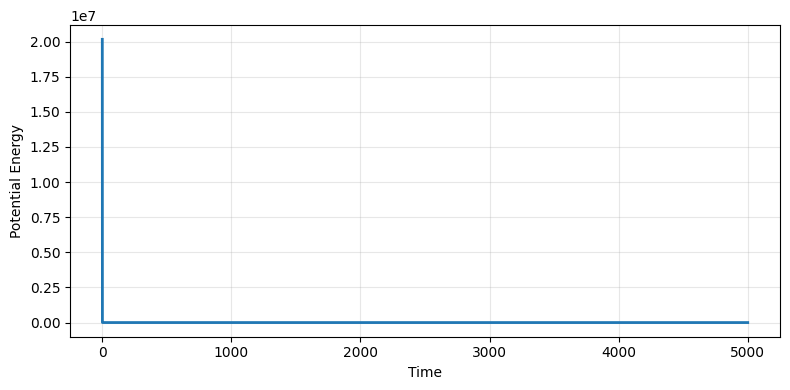

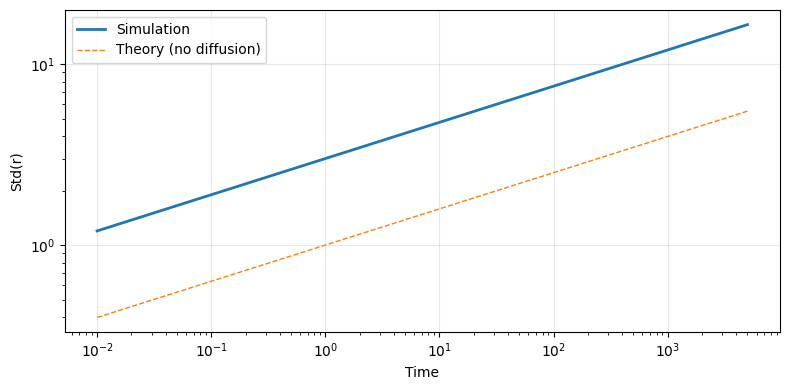

In [2]:
    
sim = load_npz("data/20260121/rk23_N1000_steps500000_dt0.01_k3.0_rtol0.001_atol0.001_w_density.npz")
plot_energy(sim)
plot_std(sim, show_theory=True)

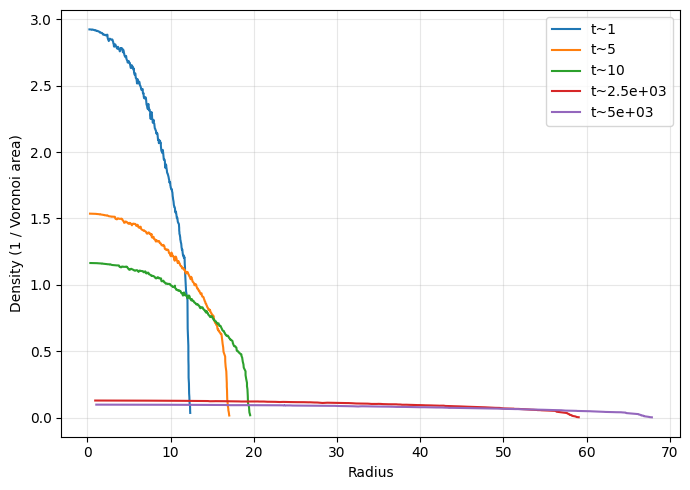

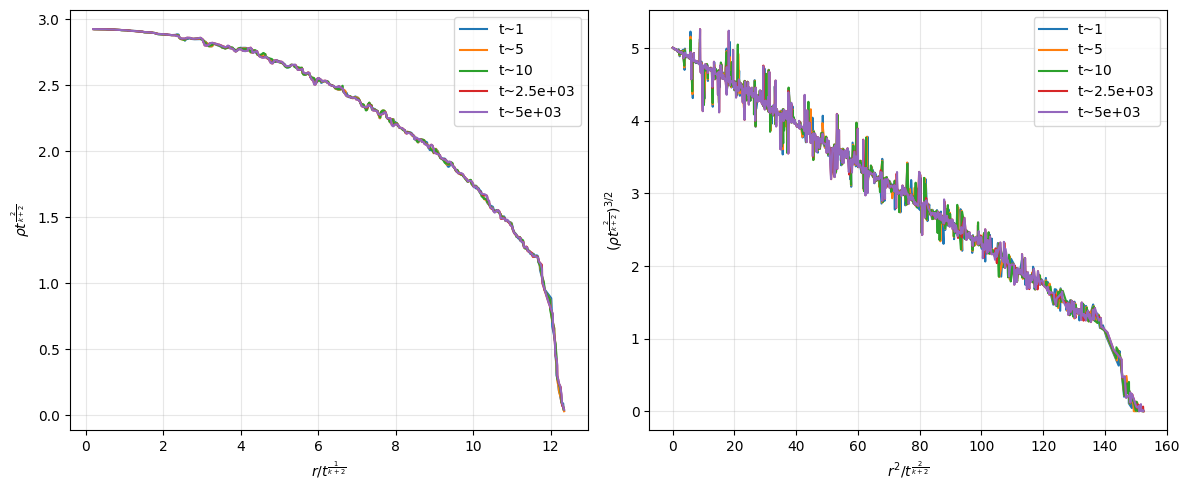

(<Figure size 1200x500 with 2 Axes>,
 (<Axes: xlabel='$r / t^{\\frac{1}{k+2}}$', ylabel='$\\rho t^{\\frac{2}{k+2}}$'>,
  <Axes: xlabel='$r^2 / t^{\\frac{2}{k+2}}$', ylabel='$(\\rho t^{\\frac{2}{k+2}})^{3/2}$'>))

In [3]:
sim = load_npz("data/20260121/rk23_N1000_steps500000_dt0.01_k3.0_rtol0.001_atol0.001_w_density.npz")
plot_density_vs_radius(                                                                                                                               
    sim,                                                                                                                                              
    times=[sim["times"][100], sim["times"][500],  sim["times"][1000], sim["times"][len(sim["times"]) // 2], sim["times"][-1]],                                                                                       
    window_frac=0.02,
    drop_zeros=True,                                                                                                                                  
    min_points=50,                                                                                                                                    
    show=True,                                                                                                                                        
)   

plot_scaled_density_vs_radius(                                                                                                                        
    sim,                                                                                                                                              
    times=[sim["times"][0], sim["times"][100], sim["times"][500],  sim["times"][1000], sim["times"][len(sim["times"]) // 2], sim["times"][-1]],                                                                                                            
    k=3.0,               # or omit if in sim["meta"]                                                                                                  
    window_frac=0.02,                                                                                                                                 
    drop_zeros=True,                                                                                                                                  
    show=True,                                                                                                                                        
) 

### K=-1,0,1 comparison

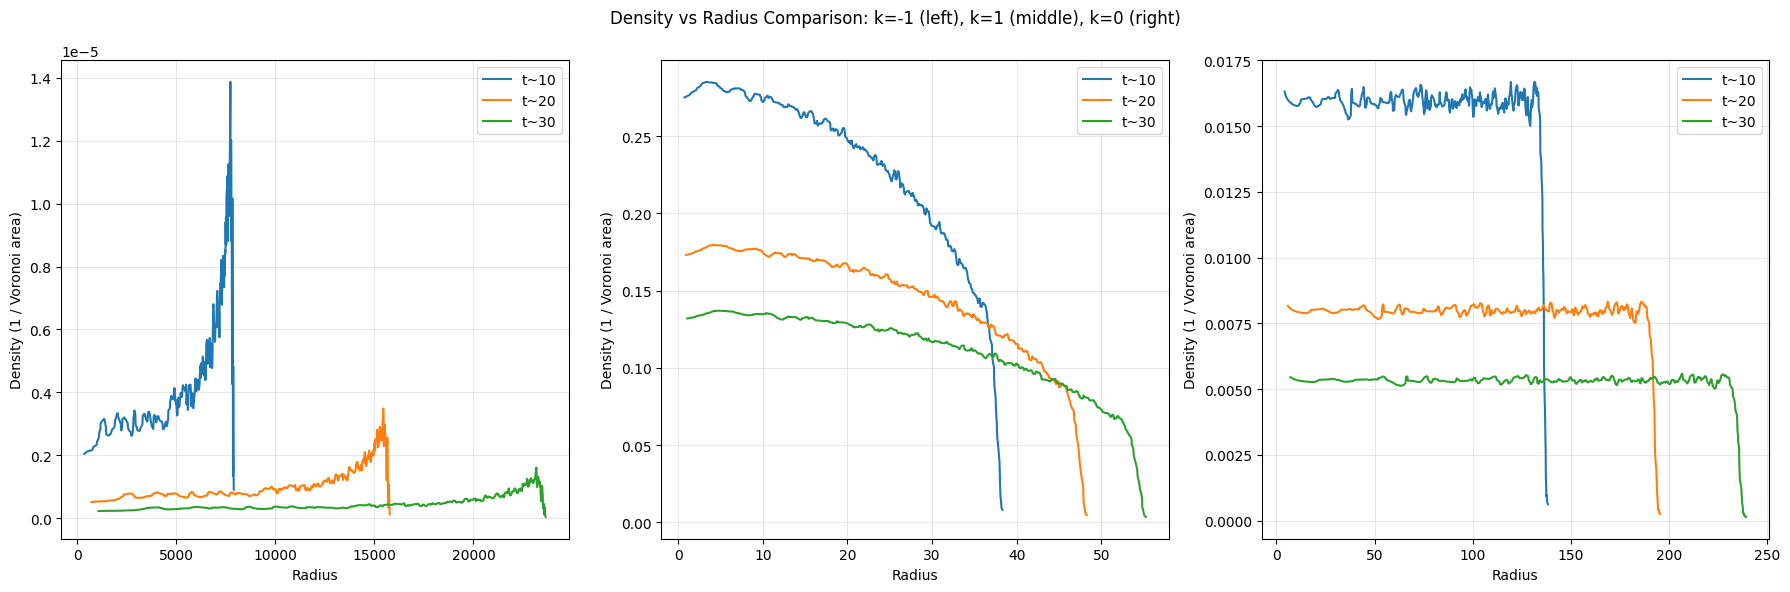

In [3]:
fig1, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
sim = load_npz("data/20260121/rk23_N1000_steps500000_dt0.01_k-1.0_rtol0.001_atol0.001_with_density.npz")
plot_density_vs_radius(                                                                                                                               
    sim,                                                                                                                                              
    times=[sim["times"][1000], sim["times"][2000], sim["times"][3000]],                                                                                       
    window_frac=0.02,
    ax=ax1,
    drop_zeros=True,                                                                                                                                  
    min_points=50,                                                                                                                                    
    show=False,                                                                                                                                        
)

sim2 = load_h5("data/20260121/rk23_N1000_steps500000_dt0.01_k1.0_rtol0.001_atol0.001_with_density.h5")
plot_density_vs_radius(                                                                                                                               
    sim2,                                                                                                                                              
    times=[sim2["times"][1000], sim2["times"][2000], sim2["times"][3000]],                                                                                       
    window_frac=0.02,
    drop_zeros=True,
    ax=ax2,                                                                                                                                  
    min_points=50,                                                                                                                                    
    show=False,                                                                                                                                        
)

sim3 = load_h5("data/20260121/rk23_N1000_steps500000_dt0.01_k0.0_rtol0.001_atol0.001_with_density.h5")
plot_density_vs_radius(                                                                                                                               
    sim3,                                                                                                                                              
    times=[sim3["times"][1000], sim3["times"][2000], sim3["times"][3000]],                                                                                       
    window_frac=0.02,
    drop_zeros=True,                                                                                                                                  
    ax=ax3,
    min_points=50,                                                                                                                                    
    show=False,                                                                                                                                        
)

fig1.suptitle("Density vs Radius Comparison: k=-1 (left), k=1 (middle), k=0 (right)")
fig1.tight_layout()
plt.show()



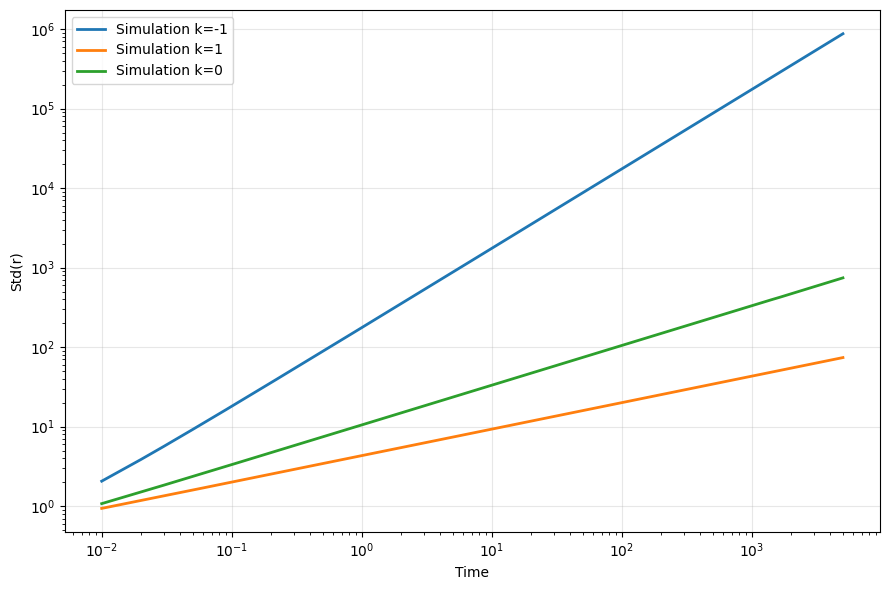

In [4]:
fig1, ax1 = plt.subplots(1, 1, figsize=(9, 6))
sim = load_npz("data/20260121/rk23_N1000_steps500000_dt0.01_k-1.0_rtol0.001_atol0.001_with_density.npz")

sim2 = load_h5("data/20260121/rk23_N1000_steps500000_dt0.01_k1.0_rtol0.001_atol0.001_with_density.h5")

sim3 = load_h5("data/20260121/rk23_N1000_steps500000_dt0.01_k0.0_rtol0.001_atol0.001_with_density.h5")

t = np.asarray(sim["times"])
s = np.asarray(sim["std"])
t1 = np.asarray(sim2["times"])
s1 = np.asarray(sim2["std"])
t2 = np.asarray(sim3["times"])
s2 = np.asarray(sim3["std"])

# log axes can't show 0
m = t > 0
t = t[m]
s = s[m]

m1 = t1 > 0
t1 = t1[m1]
s1 = s1[m1]

m2 = t2 > 0
t2 = t2[m2]
s2 = s2[m2]

plt.plot(t, s, linewidth=2, label="Simulation k=-1")
plt.plot(t1, s1, linewidth=2, label="Simulation k=1")
plt.plot(t2, s2, linewidth=2, label="Simulation k=0")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Std(r)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

fig1.suptitle("Standard Deviation Comparison")
fig1.tight_layout()
plt.show()